In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)

# Load data
df = pd.read_csv("../data/preprocessed/steam_reviews_preprocessed.csv", parse_dates=["review_timestamp_created", "review_timestamp_updated"])
df["app_release_date"] = pd.to_datetime(df["app_release_date"], format="%d %b, %Y", utc=True)

print(f"Dataset: {df.shape[0]:,} reviews  |  {df['app_name'].nunique()} games  |  {df.shape[1]} columns")

Dataset: 709,873 reviews  |  23 games  |  31 columns


In [2]:
df.sort_values("review_votes_funny", ascending=False, inplace=True)
df.reset_index(drop=True, inplace=True)
df.head()

,review_id,review_text_cleaned,review_language,review_timestamp_created,review_timestamp_updated,review_age_days,review_voted_up,review_votes_up,review_votes_funny,review_weighted_vote_score,...,app_metacritic_score,app_categories,app_genres,app_recommendations,app_release_date,label_is_funny_binary,label_funny_minmax,label_funny_log,label_funny_per_day,votes_funny_categorical
0,22390398,I started a co-op factory with a close friend....,english,2016-04-13 07:52:32+00:00,2017-10-22 18:46:45+00:00,3587,True,2970,3595,0.981391,...,90.0,"['Single-player', 'Multi-player', 'Co-op', 'On...","['Casual', 'Indie', 'Simulation', 'Strategy']",186632,2020-08-14 00:00:00+00:00,1,1.000000,8.187577,1.002230,4
1,21525836,"I got Factorio out of boredom. You see, I'm si...",english,2016-02-28 15:02:33+00:00,2016-02-28 15:02:33+00:00,3632,True,1288,2089,0.926785,...,90.0,"['Single-player', 'Multi-player', 'Co-op', 'On...","['Casual', 'Indie', 'Simulation', 'Strategy']",186632,2020-08-14 00:00:00+00:00,1,0.581085,7.644919,0.575165,4
2,208837042,Game so good that while playing I forgot I was...,english,2025-11-09 20:48:31+00:00,2025-11-09 20:48:31+00:00,89,True,5033,1809,0.967104,...,87.0,"['Single-player', 'Steam Achievements', 'Full ...","['Action', 'Adventure', 'Casual', 'Indie', 'St...",151789,2025-10-22 00:00:00+00:00,1,0.503199,7.501082,20.325843,4
3,206342558,Just remember (cod players)\r\n\r\nA high K/D ...,english,2025-10-10 15:26:09+00:00,2025-10-10 15:26:09+00:00,120,True,17393,1436,0.948122,...,82.0,"['Single-player', 'Multi-player', 'PvP', 'Onli...",['Action'],251074,2025-10-10 00:00:00+00:00,1,0.399444,7.270313,11.966667,4
4,69278868,A critical game-breaking bug doesn't allow the...,english,2020-05-17 02:14:00+00:00,2020-05-17 02:14:00+00:00,2092,False,805,1204,0.834606,...,81.0,"['Single-player', 'Multi-player', 'Co-op', 'On...","['Action', 'RPG']",125746,2020-03-13 00:00:00+00:00,1,0.334910,7.094235,0.575526,4


# Steam Review Humor — Data Exploration

## 1 · Reviews per Game: Funny vs Not Funny vs Total

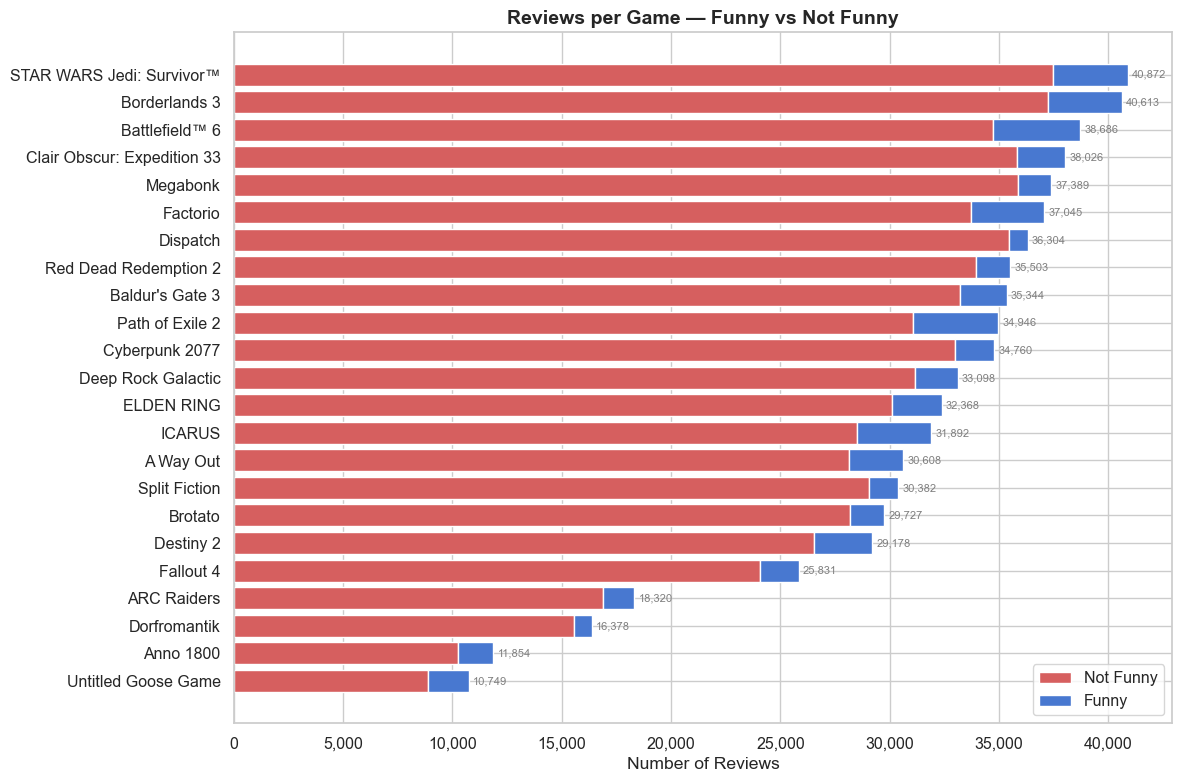

In [3]:
# --- Reviews per game: funny vs not funny (stacked) with total annotation ---
game_stats = df.groupby("app_name").agg(
    total=("review_id", "count"),
    funny=("label_is_funny_binary", "sum"),
).assign(not_funny=lambda x: x["total"] - x["funny"]).sort_values("total", ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
bars_nf = ax.barh(game_stats.index, game_stats["not_funny"], label="Not Funny", color=sns.color_palette()[3])
bars_f  = ax.barh(game_stats.index, game_stats["funny"], left=game_stats["not_funny"], label="Funny", color=sns.color_palette()[0])

for i, (_, row) in enumerate(game_stats.iterrows()):
    ax.text(row["total"] + 200, i, f'{row["total"]:,}', va="center", fontsize=8, color="grey")

ax.set_xlabel("Number of Reviews")
ax.set_title("Reviews per Game — Funny vs Not Funny", fontsize=14, fontweight="bold")
ax.legend(loc="lower right")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## 2 · Funny-Vote Ratio per Game

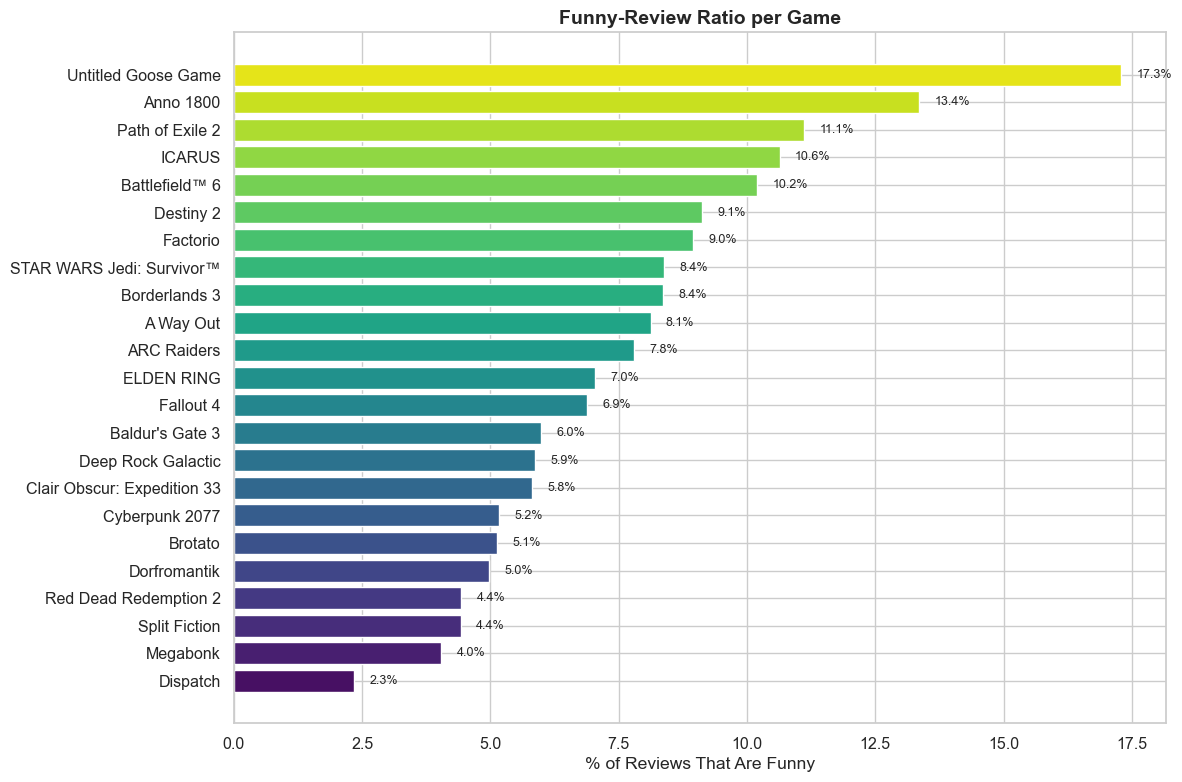

In [4]:
# --- Percentage of funny reviews per game ---
ratio = (game_stats["funny"] / game_stats["total"] * 100).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(ratio.index, ratio.values, color=sns.color_palette("viridis", len(ratio)))
for bar, val in zip(bars, ratio.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2, f"{val:.1f}%", va="center", fontsize=9)
ax.set_xlabel("% of Reviews That Are Funny")
ax.set_title("Funny-Review Ratio per Game", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 3 · Reviews Over Time (Funny vs Not Funny)

Each subplot shows a game's weekly review count for the **last 365 days**, split by humor.

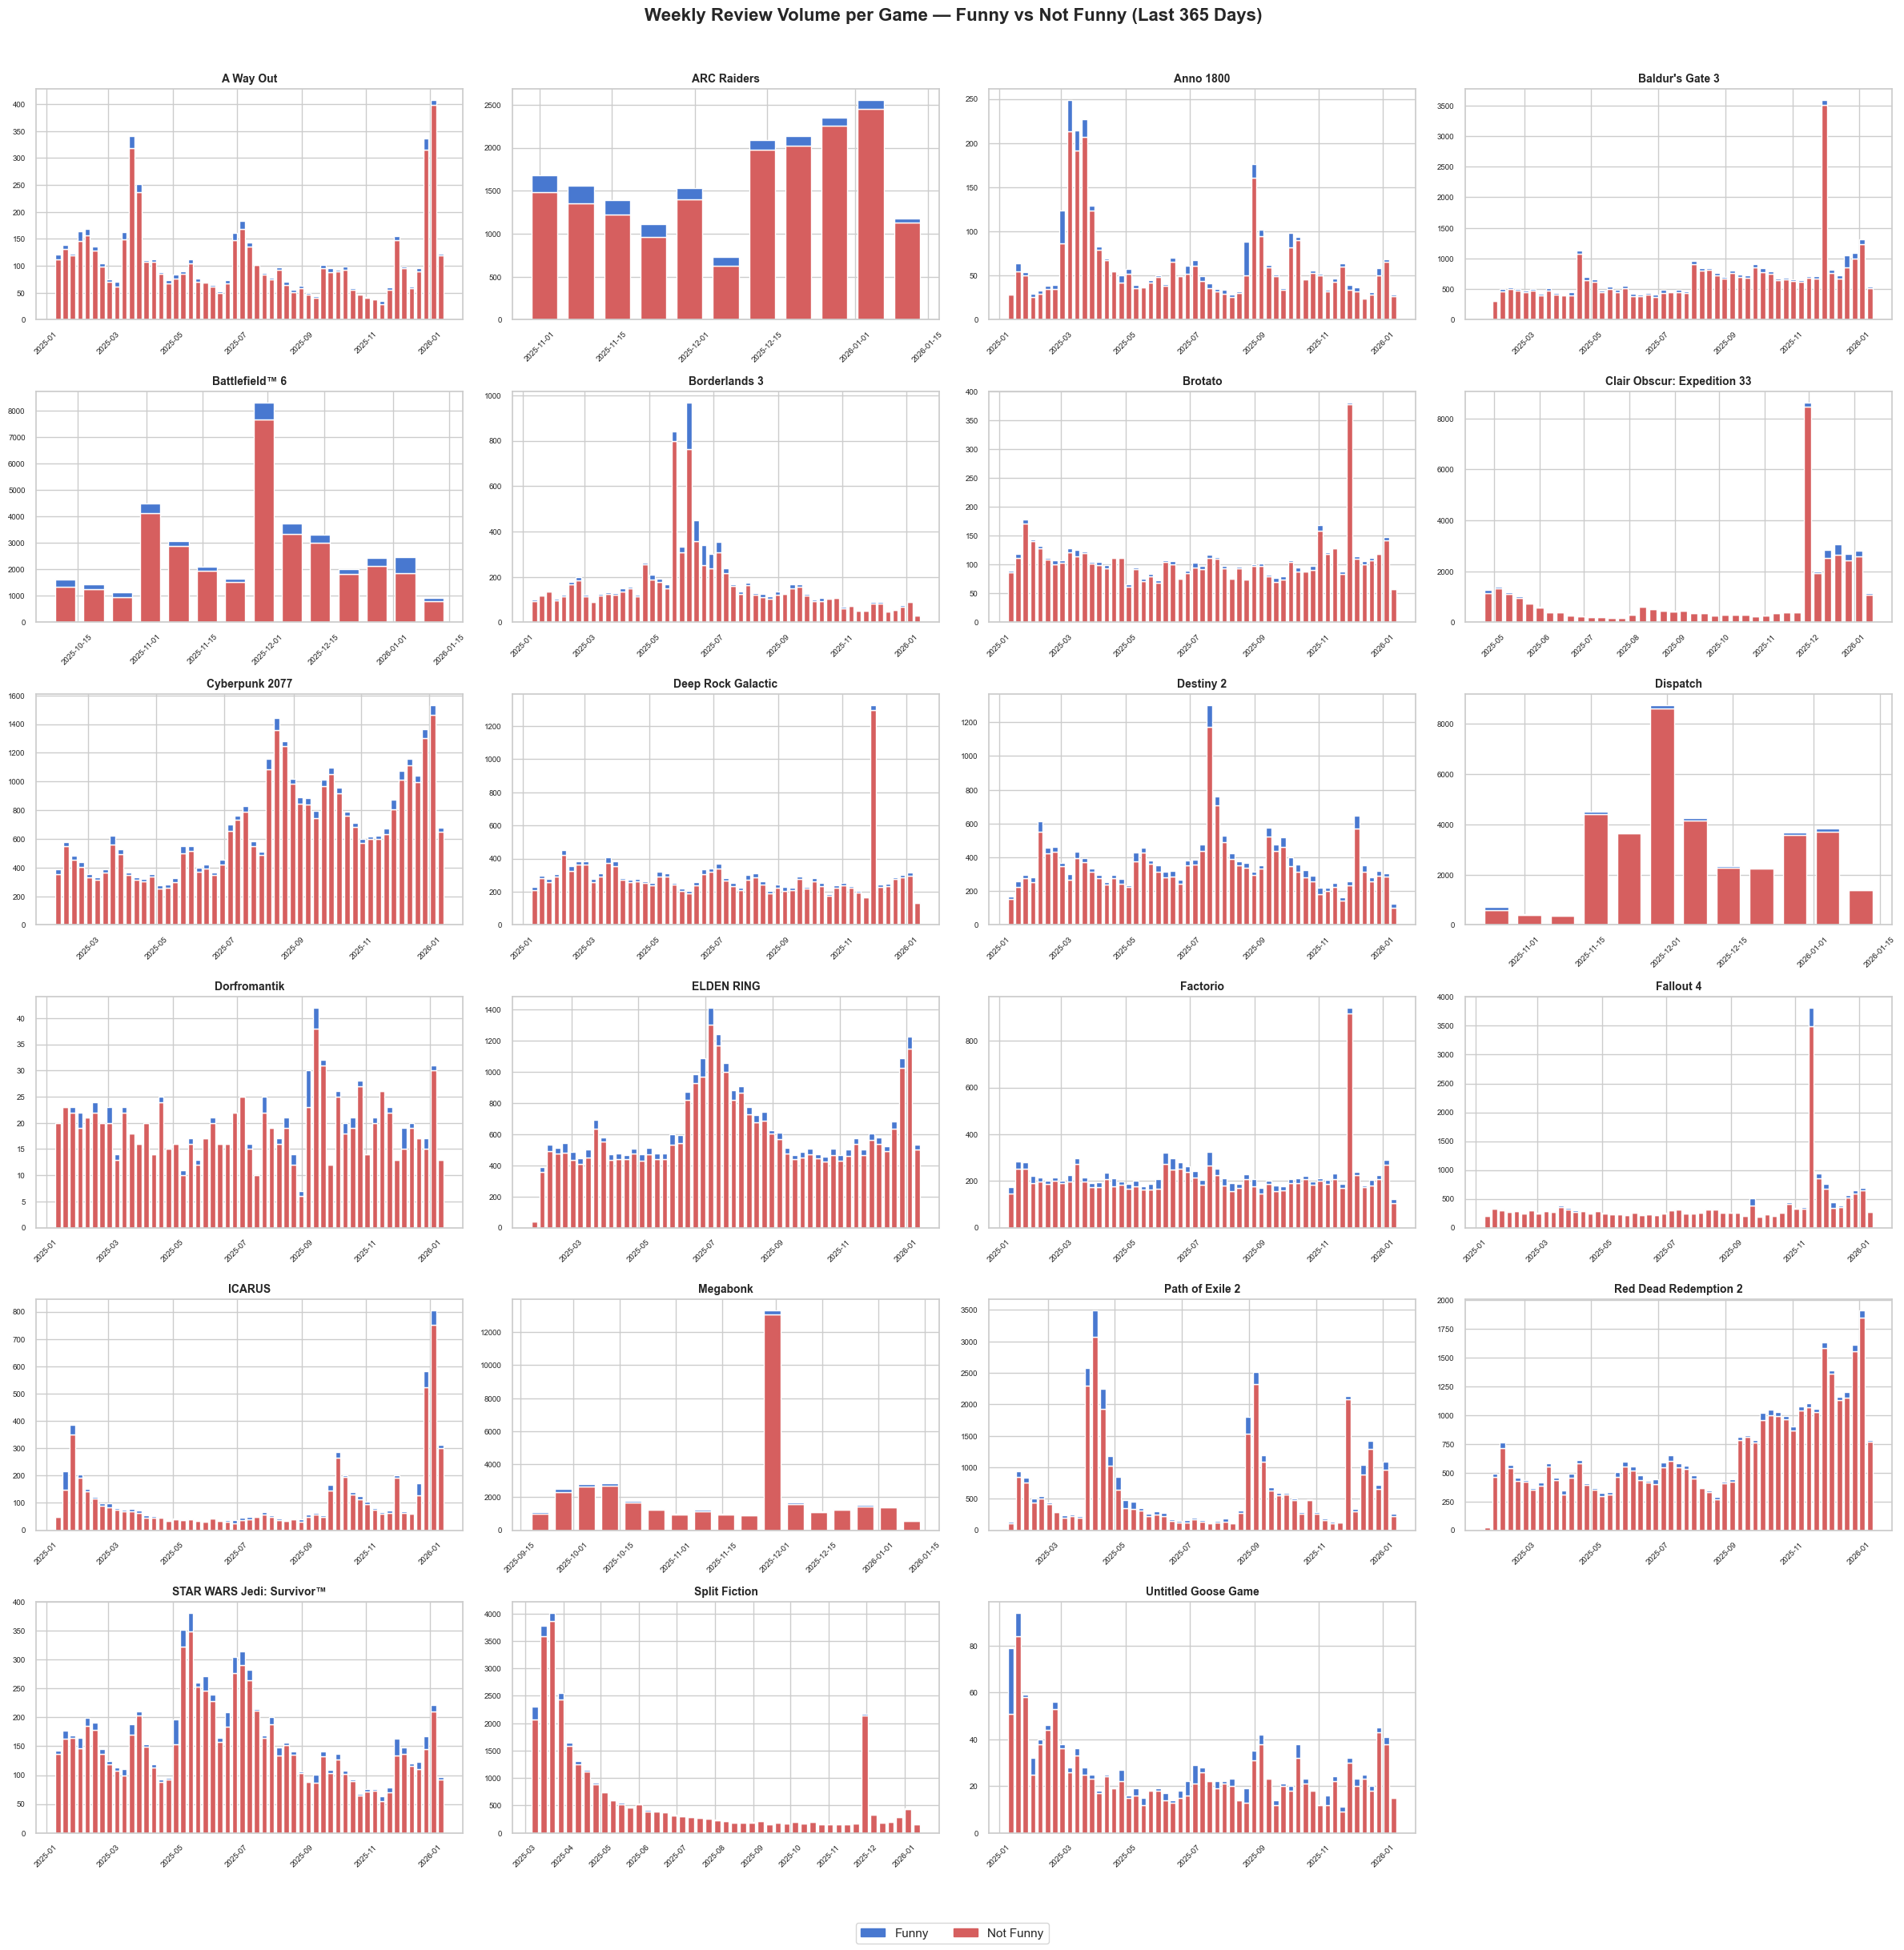

In [8]:
# --- Daily reviews since release, colour-coded by humor ---
df["days_since_release"] = (df["review_timestamp_created"] - df["app_release_date"]).dt.days

# Create a humor category column
df["review_category"] = pd.Categorical(
    df["label_is_funny_binary"].map({1: "Funny", 0: "Not Funny"}),
    categories=["Not Funny", "Funny"],
    ordered=True,
)

games_sorted = sorted(df["app_name"].unique())
n_games = len(games_sorted)
ncols = 4
nrows = int(np.ceil(n_games / ncols))

color_map = {
    "Funny": sns.color_palette()[0],      # Blue
    "Not Funny": sns.color_palette()[3],  # Red
}

fig, axes = plt.subplots(nrows, ncols, figsize=(24, nrows * 4), sharex=False, sharey=False)
axes = axes.flatten()

for idx, game in enumerate(games_sorted):
    ax = axes[idx]
    gdf = df[df["app_name"] == game]
    # Filter to last 365 days of reviews for better readability
    cutoff_date = df["review_timestamp_created"].max() - pd.Timedelta(days=365)
    gdf = gdf[gdf["review_timestamp_created"] >= cutoff_date]
    # Bin into weekly buckets for readability
    weekly = (
        gdf.groupby([pd.Grouper(key="review_timestamp_created", freq="W-SUN"), "review_category"], observed=False)
        .size()
        .unstack(fill_value=0)
    )
    # Stack bars
    bottom = np.zeros(len(weekly))
    for cat in ["Not Funny", "Funny"]:
        if cat in weekly.columns:
            ax.bar(weekly.index, weekly[cat], bottom=bottom, width=5, color=color_map[cat], label=cat)
            bottom += weekly[cat].values
    ax.set_title(game, fontsize=10, fontweight="bold")
    ax.tick_params(axis="x", labelsize=7, rotation=45)
    ax.tick_params(axis="y", labelsize=7)

# Hide unused axes
for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

# Shared legend
handles = [plt.Rectangle((0, 0), 1, 1, color=color_map[c]) for c in color_map]
fig.legend(handles, color_map.keys(), loc="lower center", ncol=2, fontsize=11, frameon=True)
fig.suptitle("Weekly Review Volume per Game — Funny vs Not Funny (Last 365 Days)", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.subplots_adjust(bottom=0.06)
plt.show()

## 4 · Funny Reviews by Label Categories

Distribution of the `votes_funny_categorical` label (0–4) across the whole dataset.

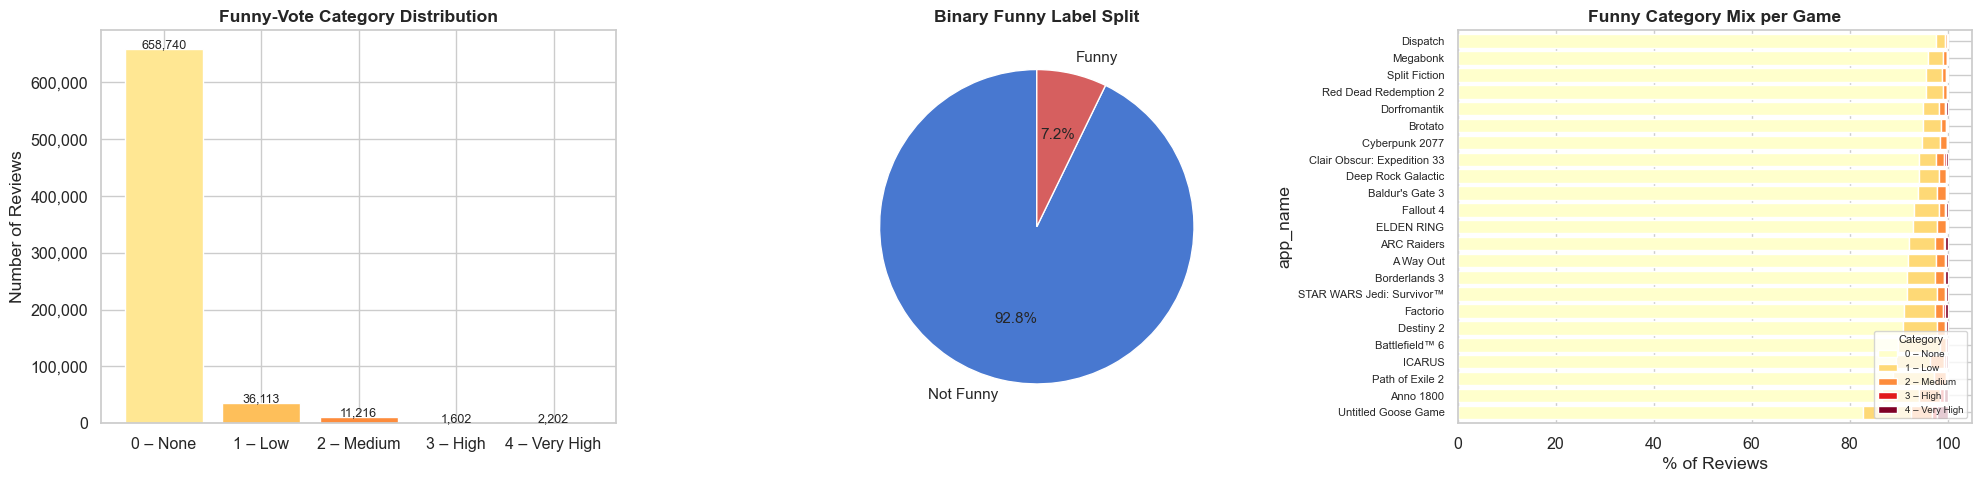

In [6]:
# --- Funny label category distributions ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 4a – Overall votes_funny_categorical distribution
cat_counts = df["votes_funny_categorical"].value_counts().sort_index()
cat_labels = {0: "0 – None", 1: "1 – Low", 2: "2 – Medium", 3: "3 – High", 4: "4 – Very High"}
ax = axes[0]
bars = ax.bar([cat_labels[c] for c in cat_counts.index], cat_counts.values, color=sns.color_palette("YlOrRd", len(cat_counts)))
for b, v in zip(bars, cat_counts.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 1000, f"{v:,}", ha="center", fontsize=9)
ax.set_title("Funny-Vote Category Distribution", fontweight="bold")
ax.set_ylabel("Number of Reviews")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# 4b – Binary funny label
ax = axes[1]
binary = df["label_is_funny_binary"].value_counts().sort_index()
wedges, texts, autotexts = ax.pie(
    binary.values, labels=["Not Funny", "Funny"], autopct="%1.1f%%",
    colors=[sns.color_palette()[0], sns.color_palette()[3]], startangle=90,
    textprops={"fontsize": 11},
)
ax.set_title("Binary Funny Label Split", fontweight="bold")

# 4c – Funny category breakdown per game (stacked %)
ax = axes[2]
ct = pd.crosstab(df["app_name"], df["votes_funny_categorical"], normalize="index") * 100
ct = ct.sort_values(0, ascending=True)
ct.columns = [cat_labels[c] for c in ct.columns]
ct.plot.barh(stacked=True, ax=ax, colormap="YlOrRd", width=0.8)
ax.set_xlabel("% of Reviews")
ax.set_title("Funny Category Mix per Game", fontweight="bold")
ax.legend(title="Category", fontsize=7, title_fontsize=8, loc="lower right")
ax.tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()

## 5 · Mean Values & Summary Statistics per Game

In [ ]:
# --- Mean metrics per game (heatmap) ---
mean_cols = [
    "review_votes_up", "review_votes_funny", "review_weighted_vote_score",
    "review_comment_count", "author_playtime_forever", "author_playtime_at_review",
    "label_is_funny_binary", "votes_funny_categorical", 
]
game_means = df.groupby("app_name")[mean_cols].mean()

# Normalise each column to 0-1 for the heatmap colours
game_means_norm = (game_means - game_means.min()) / (game_means.max() - game_means.min())

fig, ax = plt.subplots(figsize=(16, 9))
sns.heatmap(
    game_means_norm.sort_index(),
    annot=game_means.sort_index().round(2).values,
    fmt="",
    cmap="YlGnBu",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Normalised (0–1)"},
)
ax.set_title("Mean Metrics per Game (values annotated, colours normalised)", fontsize=14, fontweight="bold")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=30, labelsize=9)
ax.tick_params(axis="y", labelsize=9)
plt.tight_layout()
plt.show()

KeyError: "Columns not found: 'review_length'"

## 6 · Distribution of Funny Votes (log scale) & Playtime Comparison

In [ ]:
# --- Distributions: funny votes histogram & playtime box plots ---
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 6a – Histogram of funny votes (only reviews with ≥1 funny vote, log scale y)
funny_only = df[df["review_votes_funny"] > 0]["review_votes_funny"]
ax = axes[0]
ax.hist(funny_only, bins=100, color=sns.color_palette()[3], edgecolor="white", linewidth=0.3)
ax.set_yscale("log")
ax.set_xlabel("Funny Votes")
ax.set_ylabel("Count (log)")
ax.set_title("Distribution of Funny Votes (reviews with ≥1 vote)", fontweight="bold")
ax.axvline(funny_only.median(), color="black", ls="--", lw=1, label=f"Median = {funny_only.median():.0f}")
ax.axvline(funny_only.mean(), color="blue", ls="--", lw=1, label=f"Mean = {funny_only.mean():.1f}")
ax.legend()

# 6b – Playtime at review: funny vs not funny (box plot, capped at 99th percentile)
ax = axes[1]
cap = df["author_playtime_at_review"].quantile(0.99)
plot_df = df[df["author_playtime_at_review"] <= cap].copy()
plot_df["Is Funny"] = plot_df["label_is_funny_binary"].map({0: "Not Funny", 1: "Funny"})
sns.boxplot(data=plot_df, x="Is Funny", y="author_playtime_at_review", hue="Is Funny", ax=ax, palette=[sns.color_palette()[0], sns.color_palette()[3]], legend=False)
ax.set_ylabel("Playtime at Review (minutes)")
ax.set_title("Playtime at Review — Funny vs Not Funny", fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

## 7 · Sentiment vs Humor Crosstab & Review Length

In [ ]:
# --- Sentiment × Humor crosstab & review length distributions ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 7a – Confusion-matrix-style heatmap: sentiment vs funny
ct = pd.crosstab(
    df["review_voted_up"].map({True: "Positive", False: "Negative"}),
    df["label_is_funny_binary"].map({0: "Not Funny", 1: "Funny"}),
)
ax = axes[0]
sns.heatmap(ct, annot=True, fmt=",", cmap="Blues", ax=ax, linewidths=1)
ax.set_title("Sentiment × Humor Crosstab", fontweight="bold")
ax.set_ylabel("Review Sentiment")
ax.set_xlabel("Funny Label")

# 7b – Review text length distribution: funny vs not funny
df["review_length"] = df["review_text_cleaned"].str.len()
ax = axes[1]
for label, name, color in [(1, "Funny", sns.color_palette()[3]), (0, "Not Funny", sns.color_palette()[0])]:
    subset = df[df["label_is_funny_binary"] == label]["review_length"]
    ax.hist(subset.clip(upper=subset.quantile(0.99)), bins=80, alpha=0.6, label=name, color=color)
ax.set_xlabel("Review Length (characters)")
ax.set_ylabel("Count")
ax.set_title("Review Length Distribution — Funny vs Not Funny", fontweight="bold")
ax.legend()

# 7c – Violin plot: weighted vote score by funny category
ax = axes[2]
sns.violinplot(
    data=df, x="votes_funny_categorical", y="review_weighted_vote_score",
    hue="votes_funny_categorical", ax=ax, palette="YlOrRd", inner="quartile", cut=0, legend=False,
)
ax.set_xlabel("Funny Category (0–4)")
ax.set_ylabel("Weighted Vote Score")
ax.set_title("Weighted Vote Score by Funny Category", fontweight="bold")

plt.tight_layout()
plt.show()

## 8 · Correlation Matrix & Top Funny Reviews

In [ ]:
# --- Correlation heatmap of numeric columns ---
numeric_cols = [
    "review_votes_up", "review_votes_funny", "review_weighted_vote_score",
    "review_comment_count", "author_playtime_forever", "author_playtime_at_review",
    "review_age_days", "label_is_funny_binary", "label_funny_minmax",
    "label_funny_log", "label_funny_per_day", "votes_funny_categorical", "review_length",
]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlation Matrix of Numeric Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 9 · Steam Purchase vs Non-Purchase & Positive Rate by Humor

In [ ]:
# --- Steam purchase split & positive-review rate by humor ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 9a – Steam purchase vs key/gift, split by funny
ax = axes[0]
ct_purchase = pd.crosstab(
    df["review_steam_purchase"].map({True: "Steam Purchase", False: "Key / Gift"}),
    df["label_is_funny_binary"].map({0: "Not Funny", 1: "Funny"}),
)
ct_purchase.plot.bar(ax=ax, color=[sns.color_palette()[0], sns.color_palette()[3]], rot=0)
ax.set_title("Steam Purchase vs Key/Gift — By Humor", fontweight="bold")
ax.set_ylabel("Number of Reviews")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(title="Funny Label")

# 9b – Positive-review rate per game, funny vs not funny
ax = axes[1]
pos_rate = df.groupby(["app_name", "label_is_funny_binary"])["review_voted_up"].mean().unstack()
pos_rate.columns = ["Not Funny", "Funny"]
pos_rate = pos_rate.sort_values("Funny", ascending=True)
pos_rate.plot.barh(ax=ax, color=[sns.color_palette()[0], sns.color_palette()[3]], width=0.7)
ax.set_xlabel("Positive Review Rate")
ax.set_title("Positive-Review Rate per Game — Funny vs Not Funny", fontweight="bold")
ax.legend(title="Funny Label")
ax.tick_params(axis="y", labelsize=8)
ax.axvline(0.5, color="grey", ls=":", lw=1)

plt.tight_layout()
plt.show()

## 10 · Summary Statistics Table

In [ ]:
# --- Comprehensive summary statistics per game ---
summary = df.groupby("app_name").agg(
    total_reviews=("review_id", "count"),
    pct_positive=("review_voted_up", "mean"),
    pct_funny=("label_is_funny_binary", "mean"),
    mean_funny_votes=("review_votes_funny", "mean"),
    median_funny_votes=("review_votes_funny", "median"),
    mean_upvotes=("review_votes_up", "mean"),
    mean_playtime_hrs=("author_playtime_at_review", lambda x: x.mean() / 60),
    mean_review_length=("review_length", "mean"),
    mean_weighted_score=("review_weighted_vote_score", "mean"),
    pct_steam_purchase=("review_steam_purchase", "mean"),
).round(3)

summary["pct_positive"] = (summary["pct_positive"] * 100).round(1)
summary["pct_funny"] = (summary["pct_funny"] * 100).round(1)
summary["pct_steam_purchase"] = (summary["pct_steam_purchase"] * 100).round(1)
summary = summary.sort_values("total_reviews", ascending=False)

summary.style.format({
    "total_reviews": "{:,.0f}",
    "pct_positive": "{:.1f}%",
    "pct_funny": "{:.1f}%",
    "mean_funny_votes": "{:.2f}",
    "median_funny_votes": "{:.0f}",
    "mean_upvotes": "{:.2f}",
    "mean_playtime_hrs": "{:.1f}",
    "mean_review_length": "{:.0f}",
    "mean_weighted_score": "{:.4f}",
    "pct_steam_purchase": "{:.1f}%",
}).background_gradient(cmap="YlGnBu", subset=["pct_funny", "mean_funny_votes"])